In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(data= housing.data, columns=housing.feature_names)
df['MedHouseValue'] = pd.Series(housing.target)

inputs=df.drop(['MedHouseValue'],axis=1)
df.tail() #Menampilkan 5 data teratas

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [8]:
X = df.drop(columns=["MedHouseValue"])
y = df["MedHouseValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [5]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_test)

[[1.89659453e-01 7.45098039e-01 2.59249620e-02 ... 8.26699958e-04
  1.61530287e-01 5.94594595e-01]
 [1.01964111e-01 7.05882353e-01 2.93658328e-02 ... 1.49655077e-03
  4.50584485e-01 4.52452452e-01]
 [2.42293210e-01 8.82352941e-01 2.57625553e-02 ... 2.43712035e-03
  5.51540914e-01 1.88188188e-01]
 ...
 [1.43901463e-01 9.01960784e-01 2.71911561e-02 ... 1.63065424e-03
  5.92986185e-01 2.05205205e-01]
 [1.45508338e-01 2.35294118e-01 2.97484189e-02 ... 1.59782455e-03
  5.87672689e-01 2.06206206e-01]
 [8.33367816e-02 5.49019608e-01 1.45501245e-02 ... 1.74904890e-03
  1.65781084e-01 6.00600601e-01]]


In [9]:
lr_model =LinearRegression()
lr_model.fit(X_train,y_train)
print(f'intercept :{lr_model.intercept_}')
print(f'slope : {lr_model.coef_}')

intercept :-37.05624133152533
slope : [ 4.45822565e-01  9.68186799e-03 -1.22095112e-01  7.78599557e-01
 -7.75740400e-07 -3.37002667e-03 -4.18536747e-01 -4.33687976e-01]


MSE : 0.5305677824766758
R2 : 0.595770232606166


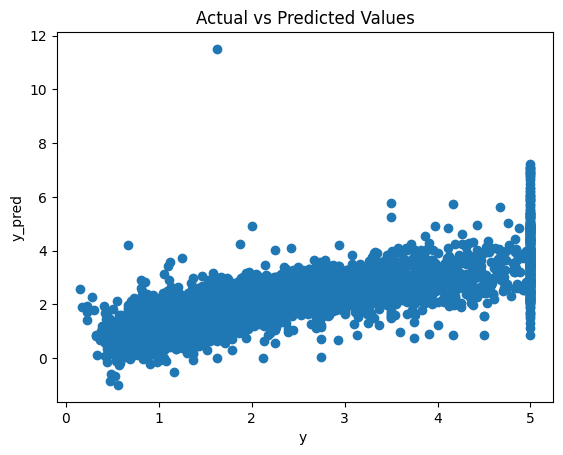

In [10]:
y_pred=lr_model.predict(X_test)

mse=mean_squared_error(y_test,y_pred)
print(f'MSE : {mse}')
r2=lr_model.score(X_test,y_test)
print(f'R2 : {r2}')
plt.scatter(y_test,y_pred)
plt.xlabel('y ')
plt.ylabel('y_pred')
plt.title('Actual vs Predicted Values')
plt.show()

In [11]:
import pickle

with open("linear_reg_california_model.pkl", "wb") as f:
    pickle.dump({"model": lr_model, "scaler": scaler}, f)

print("\nModel tersimpan: linear_reg_california_model.pkl")


Model tersimpan: linear_reg_california_model.pkl
